In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("matches.csv",sep=",",encoding ="utf8")


In [4]:
df.shape

(1095, 20)

<h3>Cleaning the Data</h3>

In [5]:
df.drop_duplicates(inplace = True)
print(df.isnull().sum())
df.shape

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


(1095, 20)

<h3>Formatting the Dates in 'date' Column</h3>

In [6]:
df['date'] = pd.to_datetime(df['date'])
df["date"] = df["date"].dt.year

In [7]:
df_Season = df.loc[df.date == 2008]
df.head(10)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
5,335987,2007/08,Jaipur,2008,League,SR Watson,Sawai Mansingh Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,bat,Rajasthan Royals,wickets,6.0,167.0,20.0,N,NaN,Aleem Dar,RB Tiffin
6,335988,2007/08,Hyderabad,2008,League,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Delhi Daredevils,Deccan Chargers,bat,Delhi Daredevils,wickets,9.0,143.0,20.0,N,NaN,IL Howell,AM Saheba
7,335989,2007/08,Chennai,2008,League,ML Hayden,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Mumbai Indians,Mumbai Indians,field,Chennai Super Kings,runs,6.0,209.0,20.0,N,NaN,DJ Harper,GA Pratapkumar
8,335990,2007/08,Hyderabad,2008,League,YK Pathan,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3.0,215.0,20.0,N,NaN,Asad Rauf,MR Benson
9,335991,2007/08,Chandigarh,2008,League,KC Sangakkara,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,Kings XI Punjab,runs,66.0,183.0,20.0,N,NaN,Aleem Dar,AM Saheba


<h3>Match Trends Over Seasons</h3>

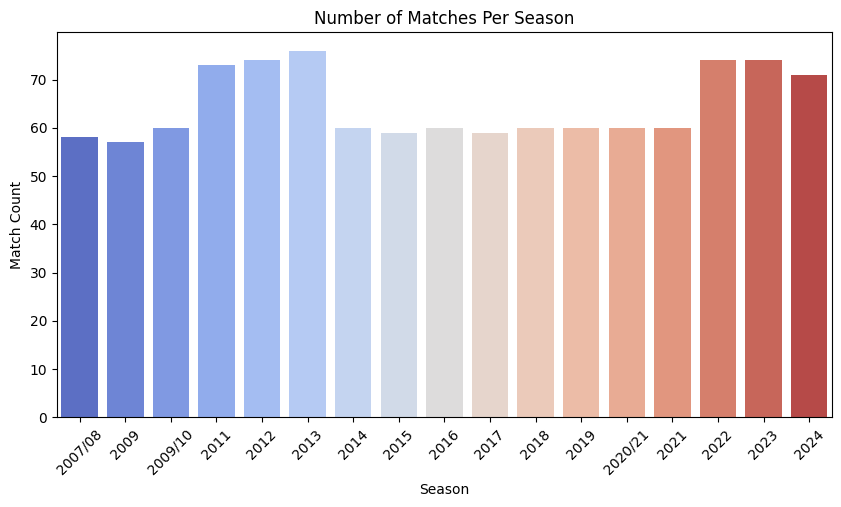

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='season', palette='coolwarm', hue='season')
plt.title('Number of Matches Per Season')
plt.xlabel('Season')
plt.ylabel('Match Count')
plt.xticks(rotation=45)
plt.show()


<h3>Team Performance Analysis</h3>

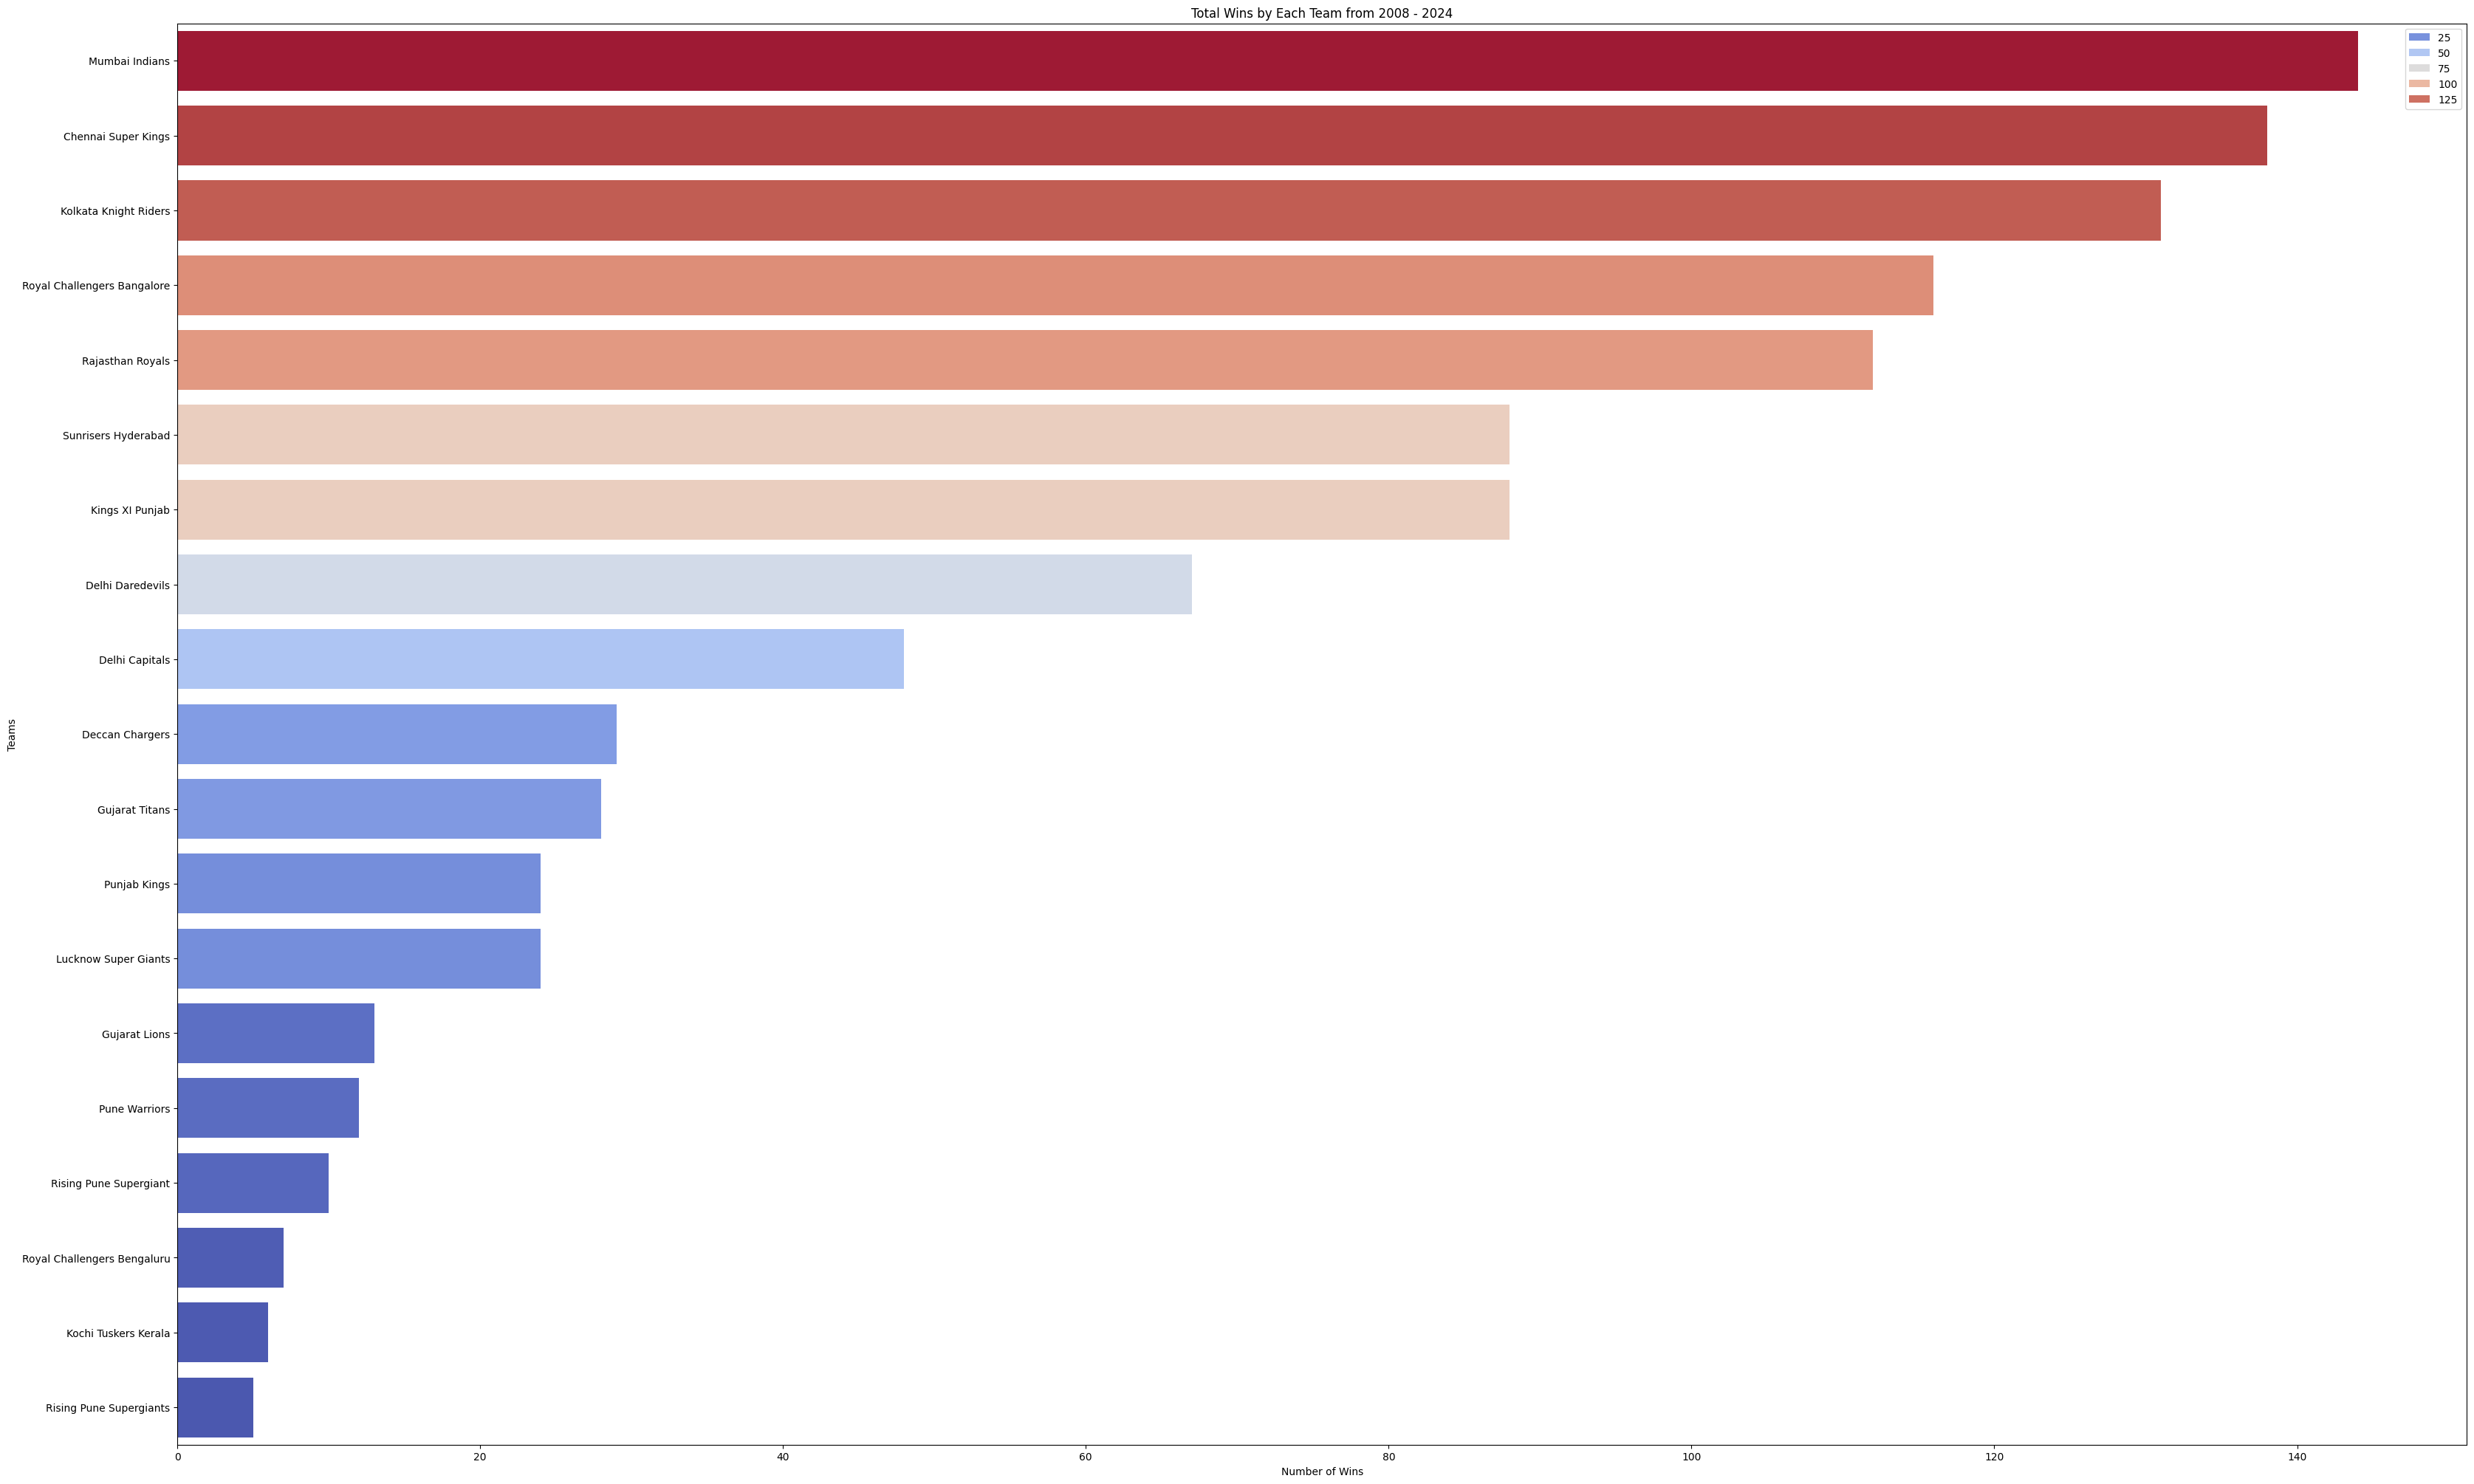

In [9]:
plt.figure(figsize=(40,25))
team_wins = df['winner'].value_counts()
sns.barplot(y=team_wins.index, x=team_wins.values,hue = team_wins.values,palette='coolwarm')
plt.title('Total Wins by Each Team from 2008 - 2024')
plt.xlabel('Number of Wins')
plt.ylabel('Teams')
plt.show()


<h3>Toss Decision Trends</h3>

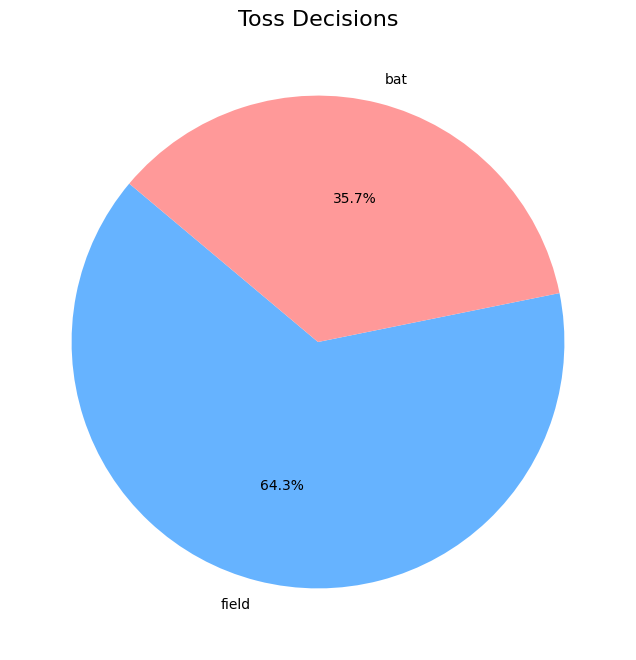

In [10]:
# Count toss decisions
toss_decision_counts = df['toss_decision'].value_counts()

# Plot
plt.figure(figsize=(8,8))
plt.pie(toss_decision_counts, labels=toss_decision_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Toss Decisions', fontsize=16)
plt.show()


<h3> Top Player of the Match Awards</h3>

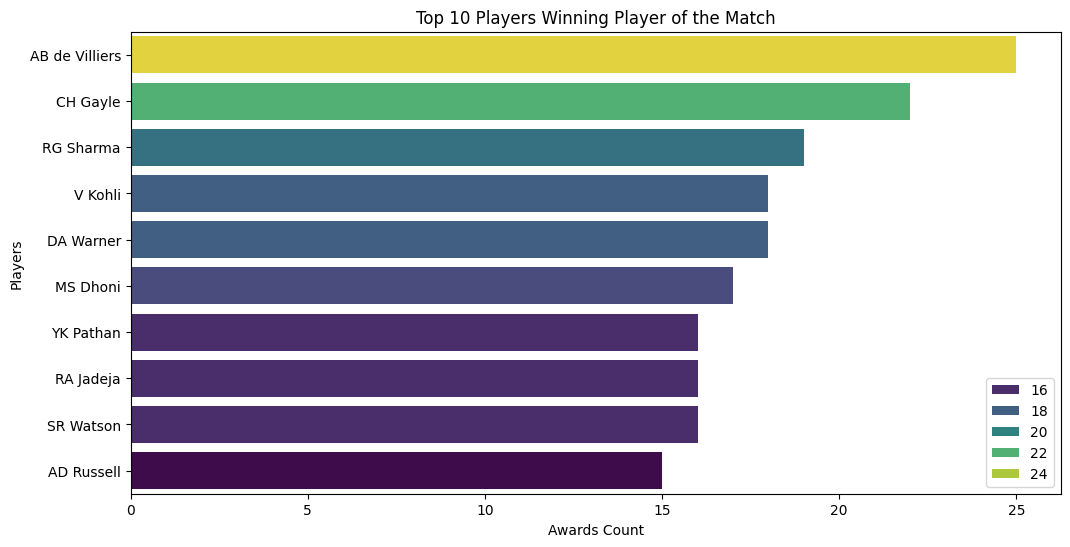

In [11]:
plt.figure(figsize=(12,6))
top_players = df['player_of_match'].value_counts()[:10]
sns.barplot(y=top_players.index, x=top_players.values,hue=top_players.values, palette='viridis')
plt.title('Top 10 Players Winning Player of the Match')
plt.xlabel('Awards Count')
plt.ylabel('Players')
plt.show()



<h3>Batting Average & Strike Rate Calculation</h3>

C:\Users\advel\AppData\Local\Temp\ipykernel_20528\615175624.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=batting_stats.head(10)['player_of_match'], x=batting_stats.head(10)['batting_avg'], palette='coolwarm')


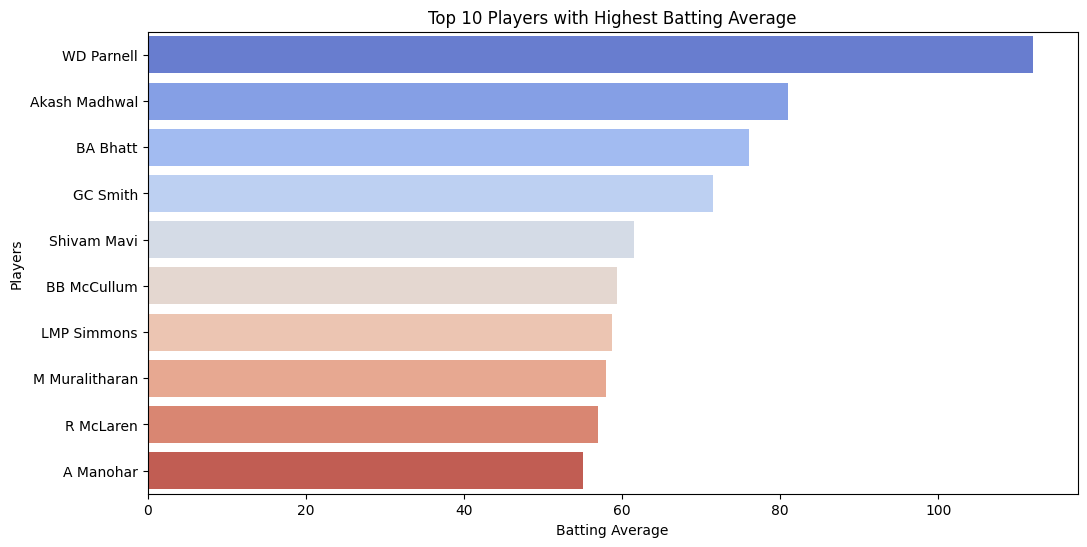

In [12]:
# Grouping by player and calculating runs scored and matches played
player_runs = df.groupby('player_of_match')['result_margin'].sum().reset_index()
player_matches = df['player_of_match'].value_counts().reset_index()
player_matches.columns = ['player', 'matches']

# Merge both dataframes
batting_stats = pd.merge(player_runs, player_matches, left_on='player_of_match', right_on='player')

# Calculating batting average
batting_stats['batting_avg'] = batting_stats['result_margin'] / batting_stats['matches']

# Sorting players by batting average
batting_stats = batting_stats.sort_values(by='batting_avg', ascending=False)

# Plot top 10 batting averages
plt.figure(figsize=(12,6))
sns.barplot(y=batting_stats.head(10)['player_of_match'], x=batting_stats.head(10)['batting_avg'], palette='coolwarm')
plt.title('Top 10 Players with Highest Batting Average')
plt.xlabel('Batting Average')
plt.ylabel('Players')
plt.show()


<h3>Venue Impact Analysis</h3>

C:\Users\advel\AppData\Local\Temp\ipykernel_20528\3755687399.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=venue_runs['venue'], x=venue_runs['result_margin'], palette='viridis')


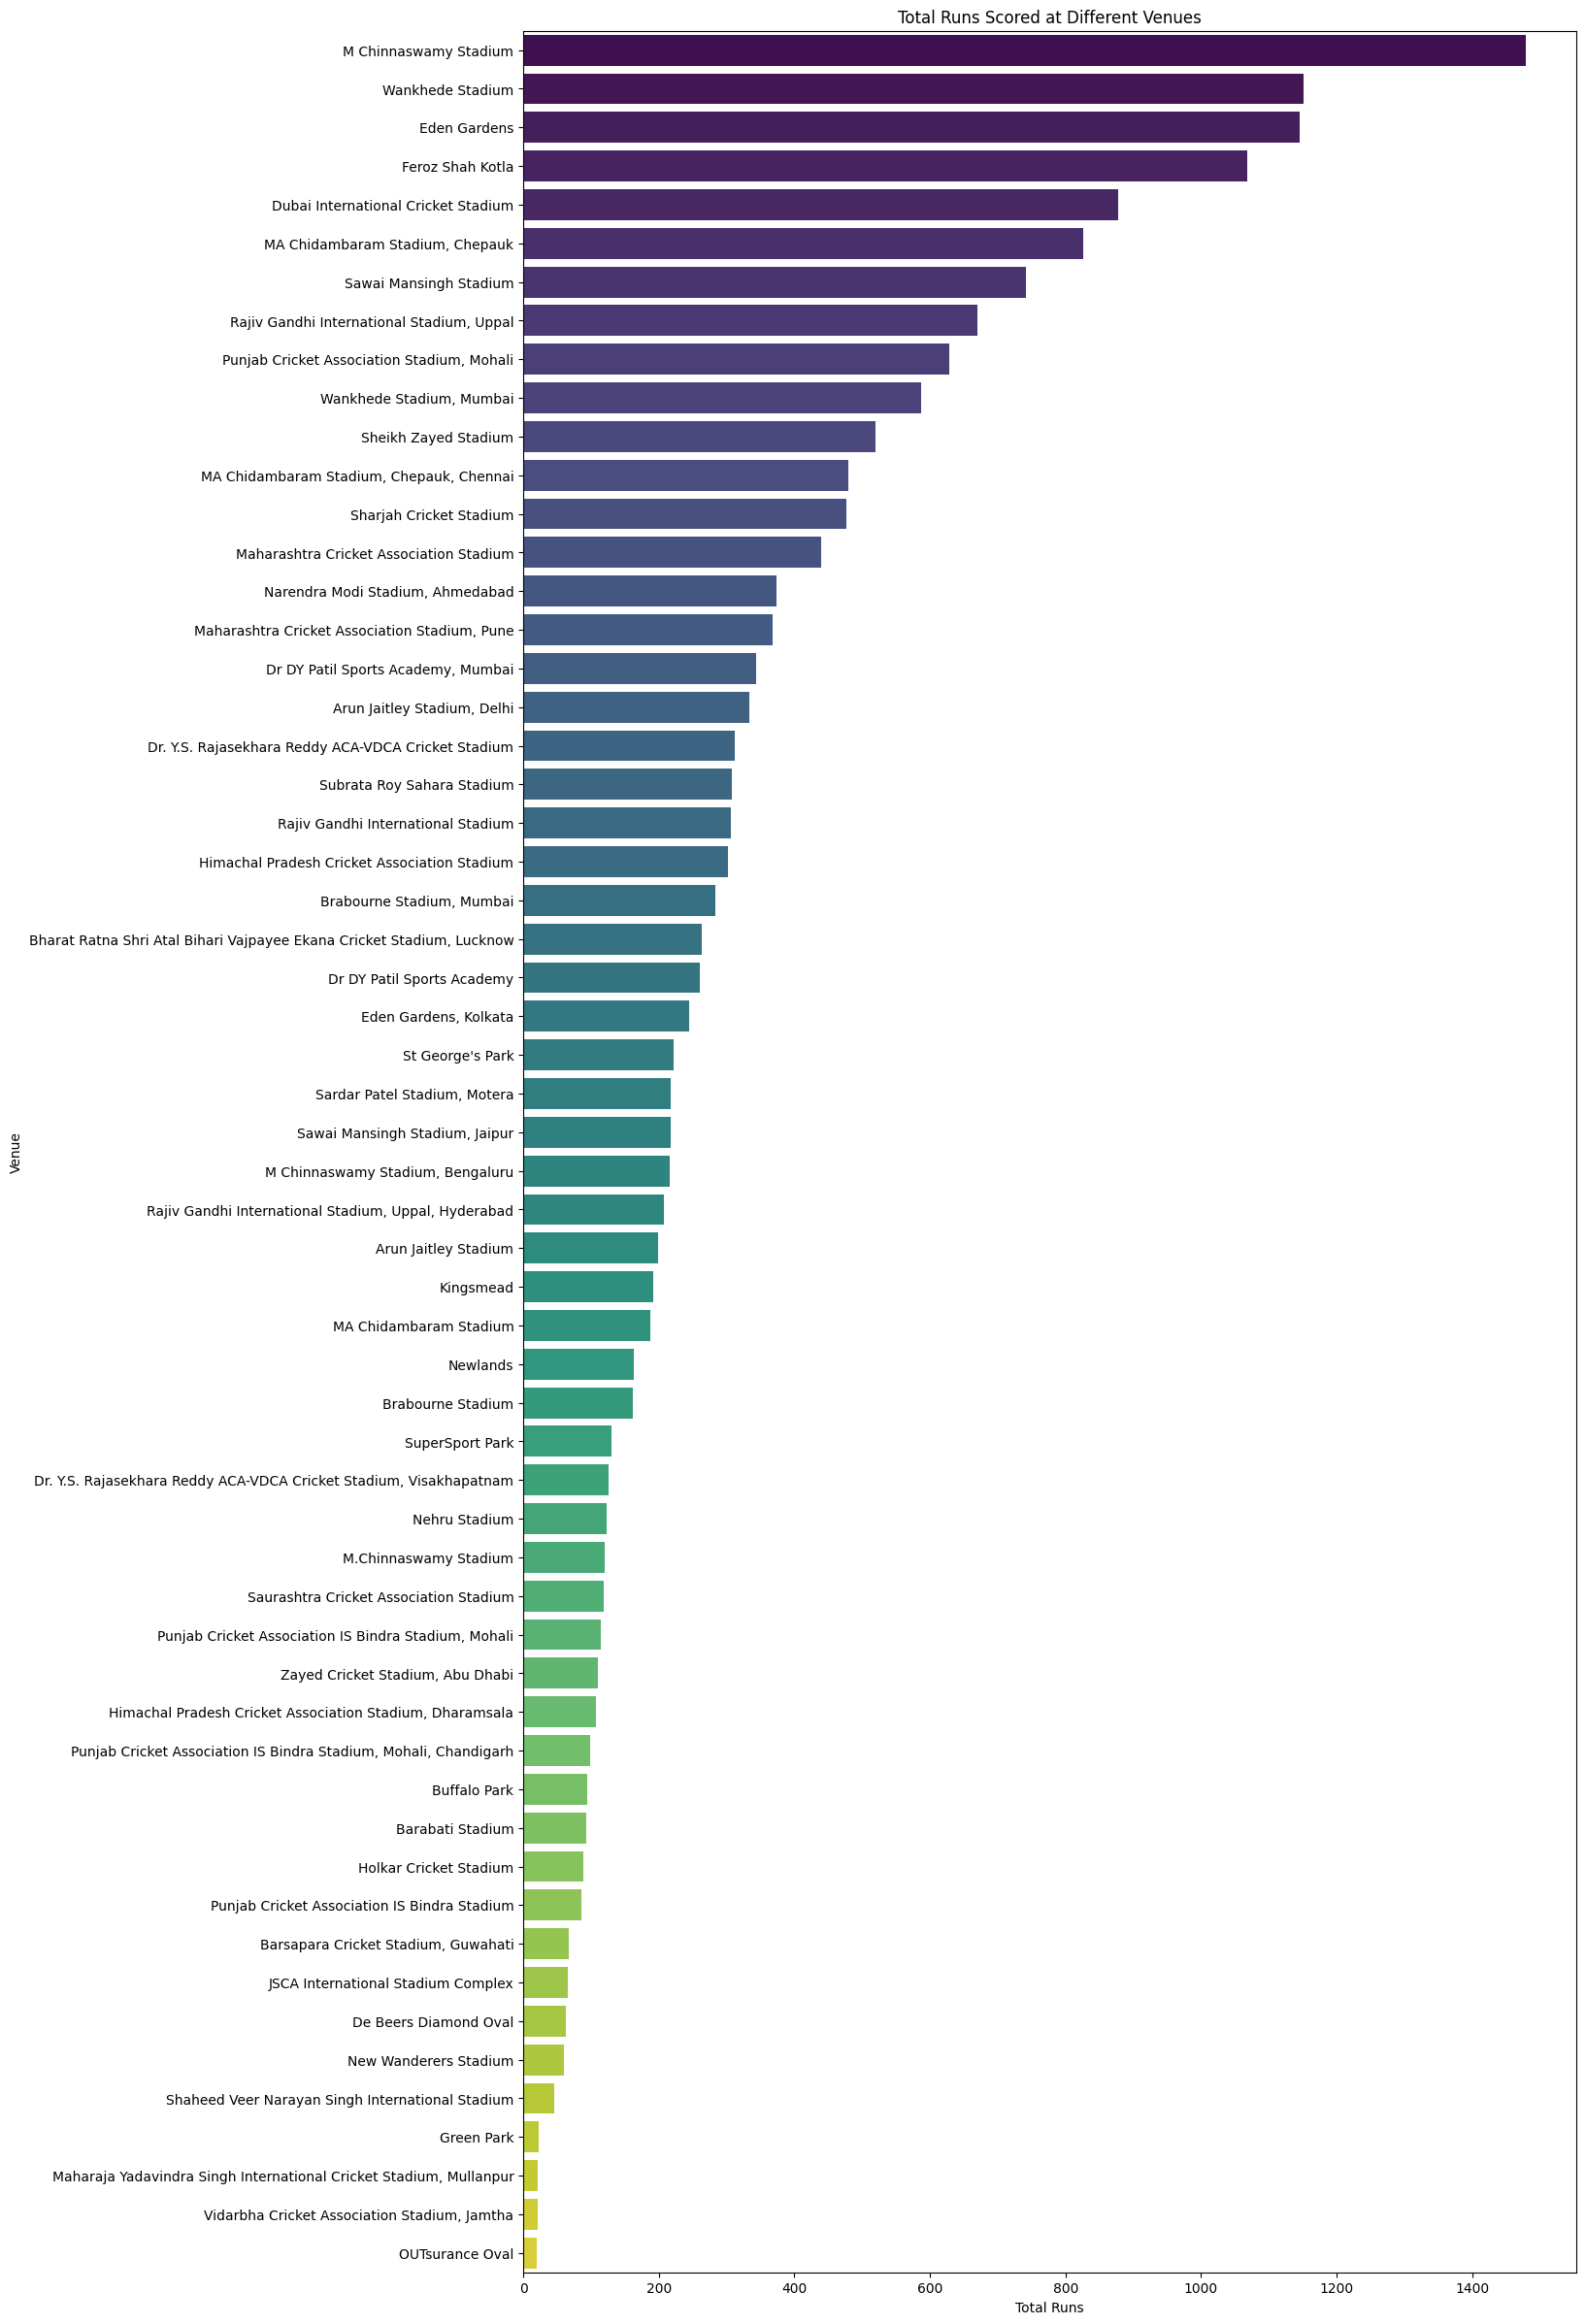

In [13]:
# Grouping by venue and calculating total runs scored
venue_runs = df.groupby('venue')['result_margin'].sum().reset_index()

# Sorting venues by total runs
venue_runs = venue_runs.sort_values(by='result_margin', ascending=False)

# Plot venue-wise scoring trends
plt.figure(figsize=(14,30))
sns.barplot(y=venue_runs['venue'], x=venue_runs['result_margin'], palette='viridis')
plt.title('Total Runs Scored at Different Venues')
plt.xlabel('Total Runs')
plt.ylabel('Venue')
plt.show()


<h3>Toss Impact on Match Outcomes</h3>

C:\Users\advel\AppData\Local\Temp\ipykernel_20528\2739371937.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=toss_effect.index, y=toss_effect.values, palette='magma')


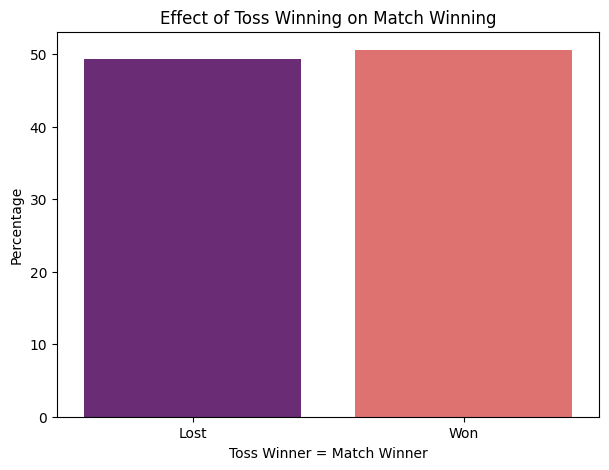

In [14]:
# Counting instances where the toss winner was also the match winner
df['toss_win_match_win'] = df['toss_winner'] == df['winner']
toss_effect = df['toss_win_match_win'].value_counts(normalize=True) * 100

# Plot toss impact
plt.figure(figsize=(7,5))
sns.barplot(x=toss_effect.index, y=toss_effect.values, palette='magma')
plt.title('Effect of Toss Winning on Match Winning')
plt.xlabel('Toss Winner = Match Winner')
plt.ylabel('Percentage')
plt.xticks([0, 1], ['Lost', 'Won'])
plt.show()


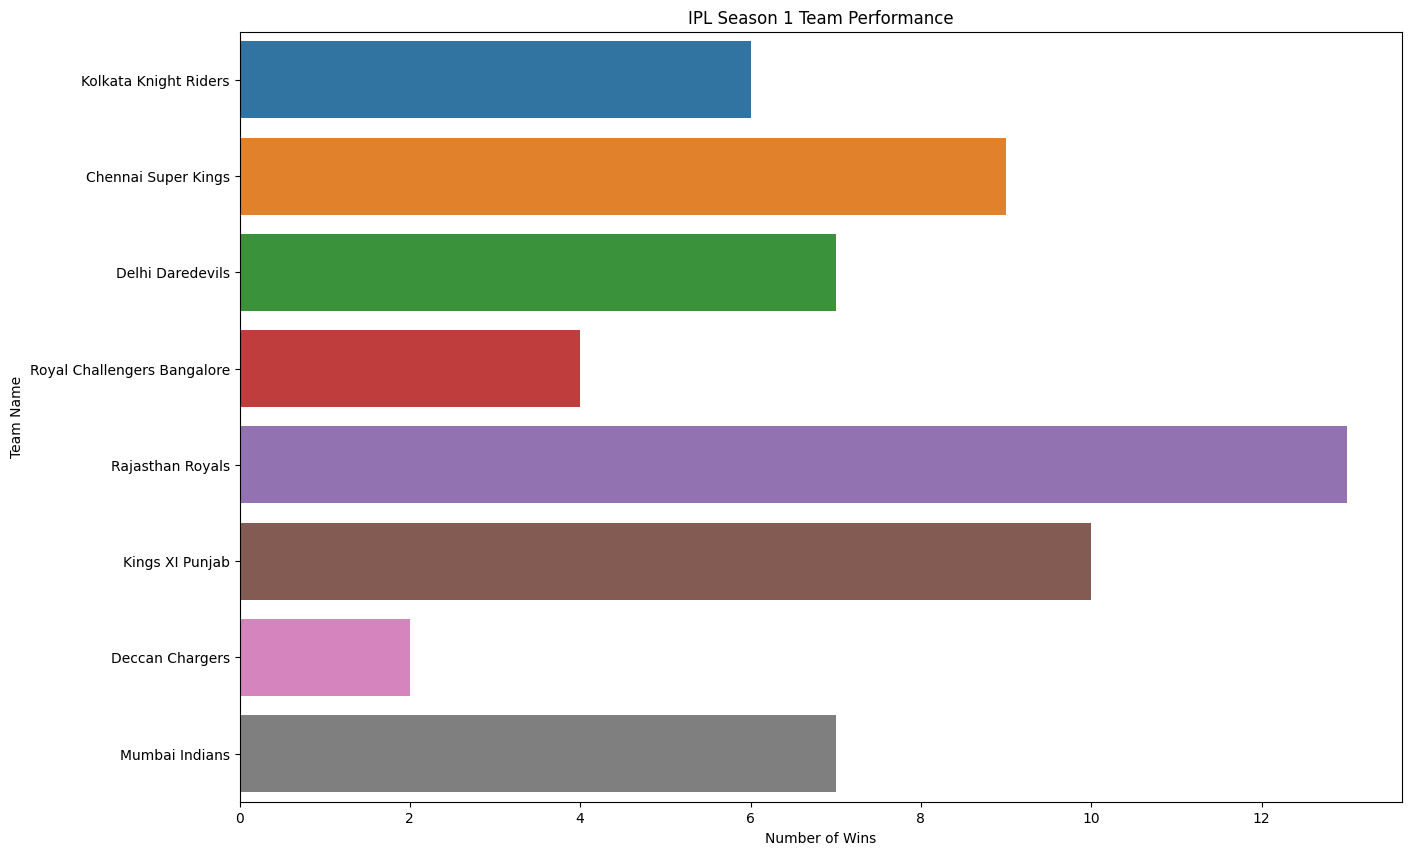

In [15]:
dfS1 = df.loc[df.season == '2007/08']
plt.figure(figsize=(15,10))
sns.countplot(y= 'winner', data = dfS1,hue='winner')
plt.title("IPL Season 1 Team Performance")
plt.xticks()
plt.xlabel("Number of Wins")
plt.ylabel("Team Name")
plt.show()

In [16]:
dfTeams = df['winner'].value_counts

In [18]:
deliveries = pd.read_csv("deliveries.csv",sep=",")

In [29]:
deliveries.head(10)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
5,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,6,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
6,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,7,BB McCullum,P Kumar,SC Ganguly,0,1,1,legbyes,0,NaN,NaN,NaN
7,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,1,BB McCullum,Z Khan,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
8,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,2,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN
9,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,3,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN


In [42]:
g1 = deliveries.groupby(["match_id","inning"])
total_runs = g1["total_runs"].agg("sum", numeric_only = True)
total_runs

match_id  inning
335982    1         222
          2          82
335983    1         240
          2         207
335984    1         129
                   ... 
1426310   2         174
1426311   1         175
          2         139
1426312   1         113
          2         114
Name: total_runs, Length: 2217, dtype: int64

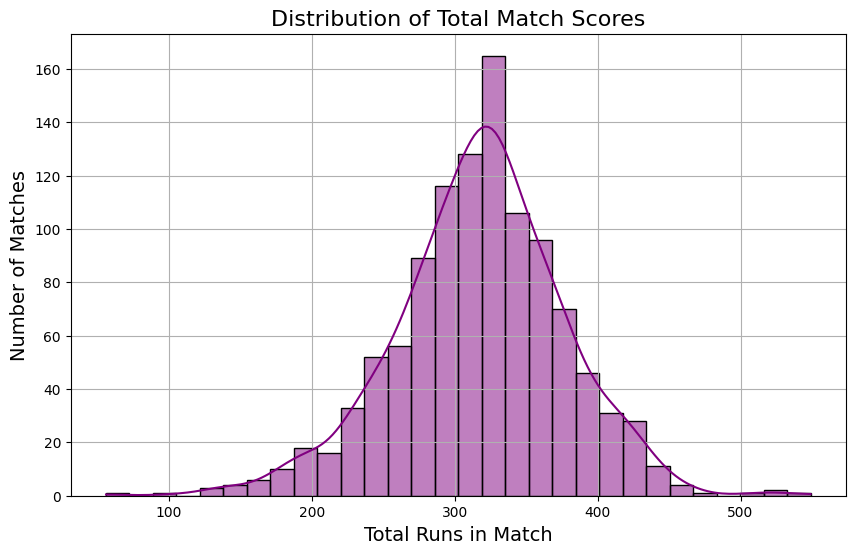

In [45]:
# Calculate total runs per match
total_runs_per_match = deliveries.groupby('match_id')['total_runs'].sum()

# Plot
plt.figure(figsize=(10,6))
sns.histplot(total_runs_per_match, kde=True, bins=30, color='purple')
plt.title('Distribution of Total Match Scores', fontsize=16)
plt.xlabel('Total Runs in Match', fontsize=14)
plt.ylabel('Number of Matches', fontsize=14)
plt.grid(True)
plt.show()


In [82]:
batsman_runs = deliveries.groupby(["batter"])["batsman_runs"].sum().sort_values(ascending=False).head(10)

In [88]:
batsman_runs

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

C:\Users\advel\AppData\Local\Temp\ipykernel_20528\308969587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=batsman_runs.values, y= batsman_runs.index, palette="magma")


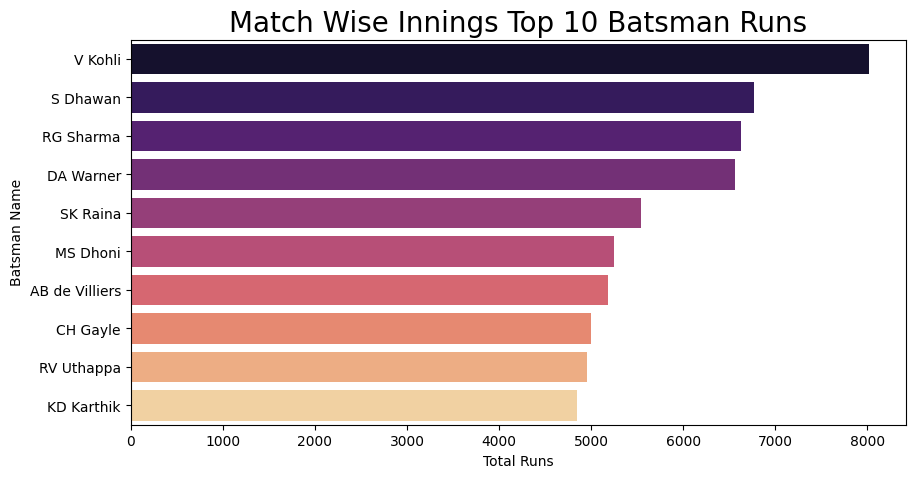

In [89]:
plt.figure(figsize=(10,5))
sns.barplot(x=batsman_runs.values, y= batsman_runs.index, palette="magma")
plt.title("Match Wise Innings Top 10 Batsman Runs", fontsize = 20)
plt.xlabel("Total Runs")
plt.ylabel("Batsman Name")
plt.show()

<h2>Dismissal Type distribution</h2>

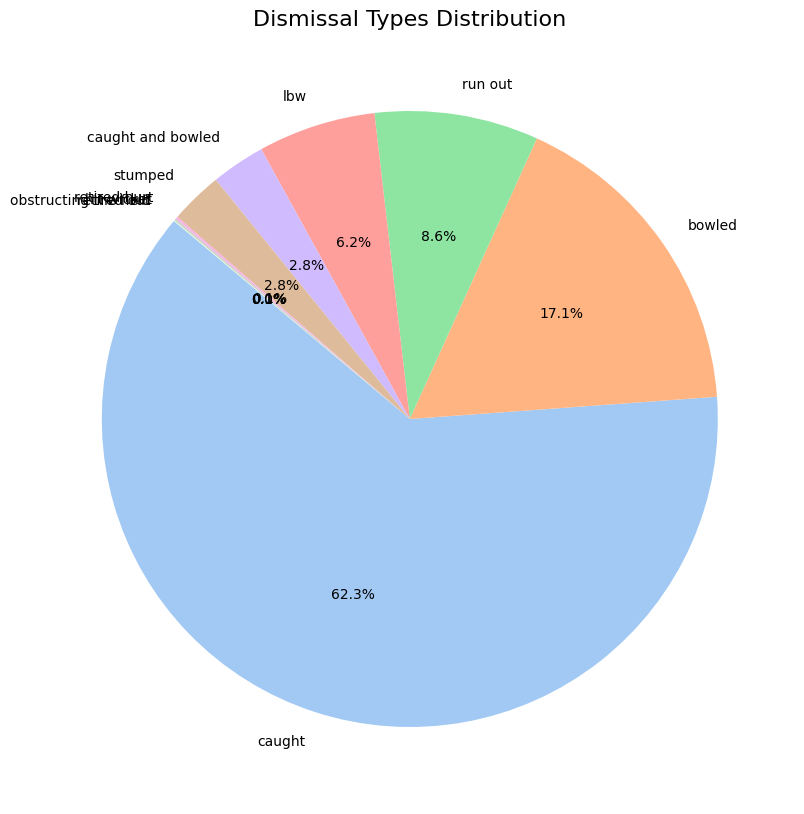

In [95]:
# Count of each dismissal type (excluding NaN)
dismissal_types = deliveries['dismissal_kind'].value_counts()

# Plot
plt.figure(figsize=(15,10))
plt.pie(dismissal_types, labels=dismissal_types.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Dismissal Types Distribution', fontsize=16)
plt.show()


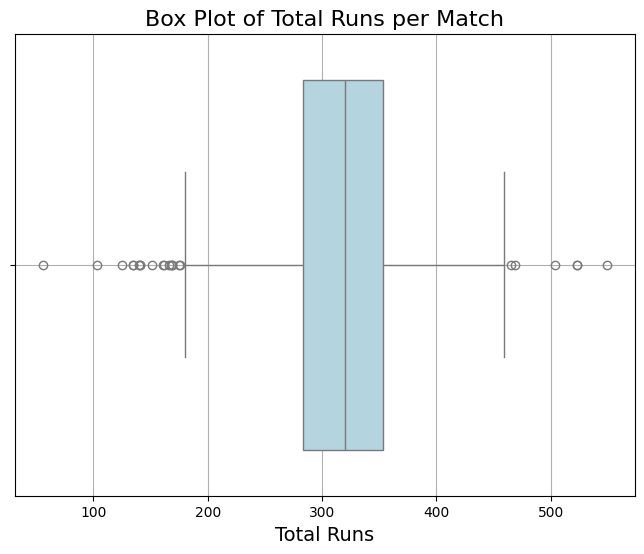

In [96]:
# Total runs per match (already calculated before, but repeating if needed)
total_runs_per_match = deliveries.groupby('match_id')['total_runs'].sum()

# Plot
plt.figure(figsize=(8,6))
sns.boxplot(x=total_runs_per_match, color='lightblue')
plt.title('Box Plot of Total Runs per Match', fontsize=16)
plt.xlabel('Total Runs', fontsize=14)
plt.grid(True)
plt.show()


In [115]:
runs_Innings = deliveries.groupby(["match_id","inning"])["total_runs"].sum()

In [129]:
runs_Innings = runs_Innings.reset_index()
runs_Innings

ValueError: cannot insert level_0, already exists

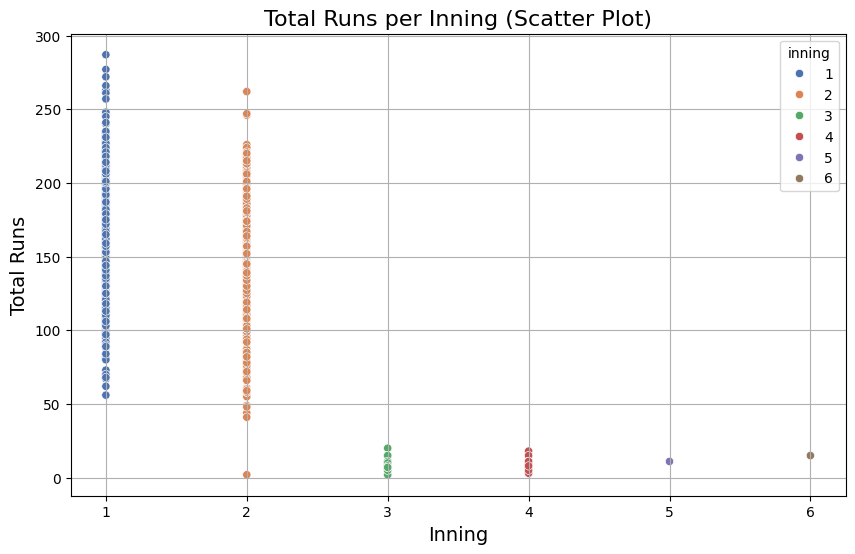

In [130]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='inning', y='total_runs', data=runs_Innings, hue='inning', palette='deep')
plt.title('Total Runs per Inning (Scatter Plot)', fontsize=16)
plt.xlabel('Inning', fontsize=14)
plt.ylabel('Total Runs', fontsize=14)
plt.grid(True)
plt.show()


<h2>📊 Average Score by Batting Team </h2>

In [169]:
# First, group by batting team and match_id, then sum total runs
team_runs = deliveries.groupby(['batting_team', 'match_id'])["total_runs"].sum().reset_index()
team_runs


,batting_team,match_id,total_runs
0,Chennai Super Kings,335983,240
1,Chennai Super Kings,335989,208
2,Chennai Super Kings,335993,152
3,Chennai Super Kings,335996,178
4,Chennai Super Kings,336001,169
...,...,...,...
2182,Sunrisers Hyderabad,1426295,167
2183,Sunrisers Hyderabad,1426307,215
2184,Sunrisers Hyderabad,1426309,159
2185,Sunrisers Hyderabad,1426311,175


In [140]:
average_team_scores = team_runs.groupby(["batting_team"])["total_runs"].mean().sort_values(ascending=False)

In [166]:
average_team_scores

batting_team
Royal Challengers Bengaluru    195.333333
Gujarat Titans                 172.377778
Lucknow Super Giants           170.681818
Punjab Kings                   170.285714
Delhi Capitals                 163.736264
Chennai Super Kings            162.991561
Gujarat Lions                  162.066667
Mumbai Indians                 161.593870
Sunrisers Hyderabad            159.730769
Kings XI Punjab                158.231579
Rajasthan Royals               157.940909
Royal Challengers Bangalore    157.050000
Kolkata Knight Riders          156.697211
Rising Pune Supergiant         154.375000
Deccan Chargers                152.840000
Delhi Daredevils               150.906832
Rising Pune Supergiants        147.357143
Pune Warriors                  141.288889
Kochi Tuskers Kerala           135.785714
Name: total_runs, dtype: float64

C:\Users\advel\AppData\Local\Temp\ipykernel_20528\2453498864.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_team_scores.values, y=average_team_scores.index, palette='cubehelix')


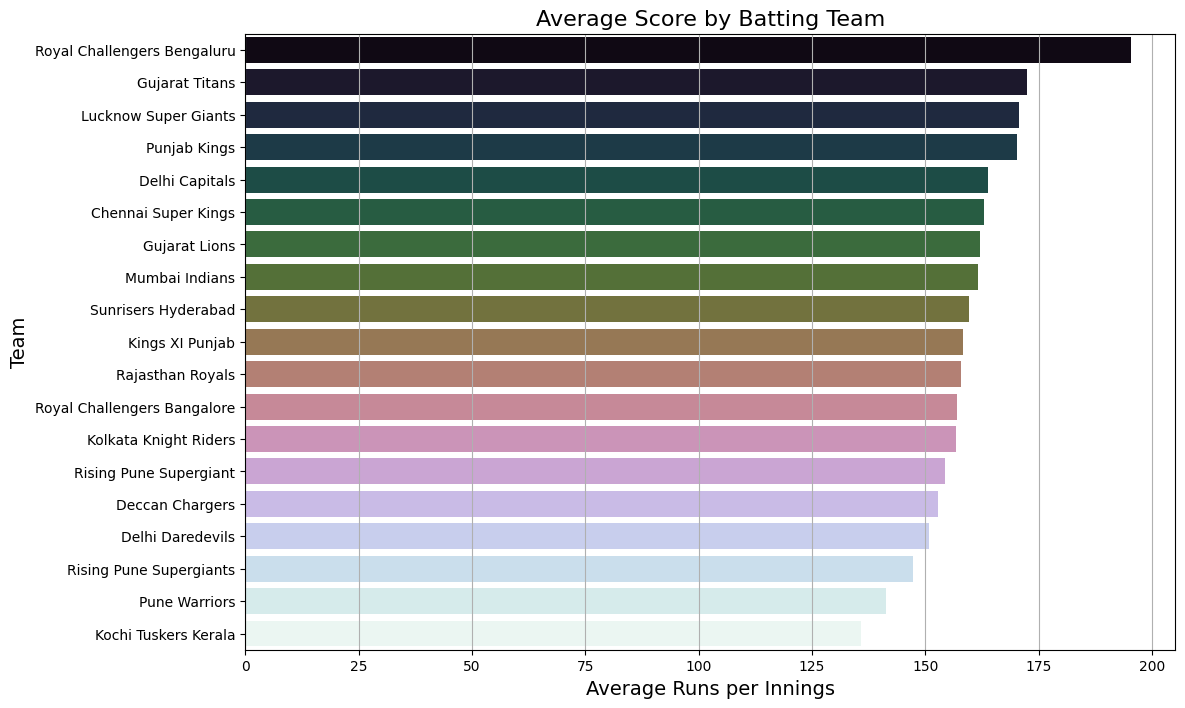

In [143]:
# Plot
plt.figure(figsize=(12,8))
sns.barplot(x=average_team_scores.values, y=average_team_scores.index, palette='cubehelix')
plt.title('Average Score by Batting Team', fontsize=16)
plt.xlabel('Average Runs per Innings', fontsize=14)
plt.ylabel('Team', fontsize=14)
plt.grid(axis='x')
plt.show()


<h2>Top Wicket Takers</h2>

In [144]:
valid_dismissals = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']


In [157]:
wicket = deliveries.loc[deliveries["dismissal_kind"].isin(valid_dismissals)].reset_index()
wicket

,index,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,33,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,5,2,SC Ganguly,Z Khan,BB McCullum,0,0,0,NaN,1,SC Ganguly,caught,JH Kallis
1,74,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,12,1,RT Ponting,JH Kallis,BB McCullum,0,0,0,NaN,1,RT Ponting,caught,P Kumar
2,106,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,17,1,DJ Hussey,AA Noffke,BB McCullum,0,0,0,NaN,1,DJ Hussey,caught,CL White
3,131,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,1,1,R Dravid,I Sharma,W Jaffer,0,0,0,NaN,1,R Dravid,bowled,NaN
4,138,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,2,2,V Kohli,AB Dinda,W Jaffer,0,0,0,NaN,1,V Kohli,bowled,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11810,260826,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,14,1,H Klaasen,Harshit Rana,PJ Cummins,0,0,0,NaN,1,H Klaasen,bowled,NaN
11811,260848,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,17,5,JD Unadkat,SP Narine,PJ Cummins,0,0,0,NaN,1,JD Unadkat,lbw,NaN
11812,260852,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,18,3,PJ Cummins,AD Russell,B Kumar,0,0,0,NaN,1,PJ Cummins,caught,MA Starc
11813,260861,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,1,2,SP Narine,PJ Cummins,Rahmanullah Gurbaz,0,0,0,NaN,1,SP Narine,caught,Shahbaz Ahmed


In [183]:
total_wickets = wicket.groupby("bowler")["dismissal_kind"].count().sort_values(ascending=False).head(10)
total_wickets


bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
R Ashwin      180
SP Narine     180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
Name: dismissal_kind, dtype: int64

C:\Users\advel\AppData\Local\Temp\ipykernel_20528\4134005553.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_wickets.values, y=total_wickets.index, palette="crest")


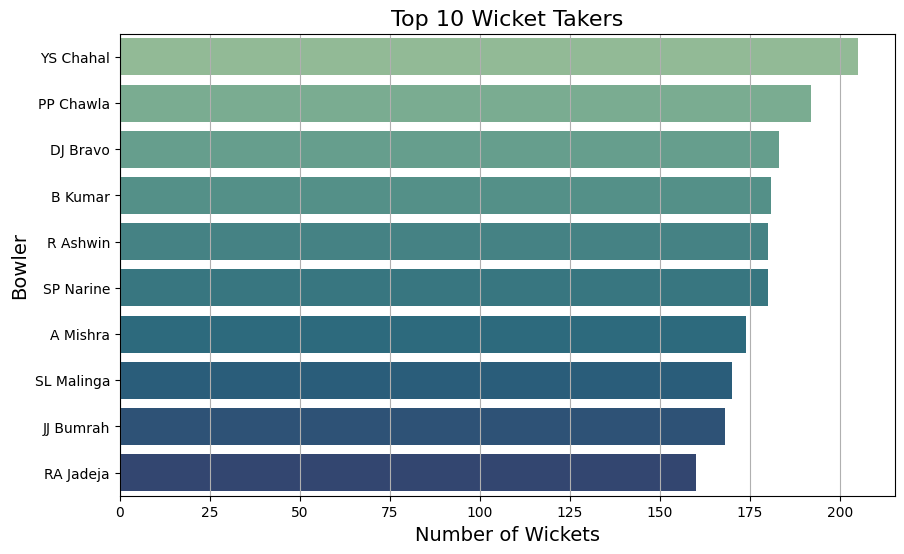

In [184]:
plt.figure(figsize=(10,6))
sns.barplot(x=total_wickets.values, y=total_wickets.index, palette="crest")
plt.

<h2>🎯 Sixes and Fours Hit by Top Players</h2>

In [185]:
batsman4s = deliveries.loc[deliveries["batsman_runs"] == 4]

In [194]:
total_4s = batsman4s.groupby(["batter"])["batsman_runs"].count().sort_values(ascending=False).head(10)

In [195]:
total_4s

batter
S Dhawan        768
V Kohli         708
DA Warner       663
RG Sharma       599
SK Raina        506
G Gambhir       492
RV Uthappa      481
AM Rahane       479
KD Karthik      466
F du Plessis    422
Name: batsman_runs, dtype: int64

In [199]:
batsman6s = deliveries.loc[deliveries["batsman_runs"] == 6]
total_6s = batsman6s.groupby(["batter"])["batsman_runs"].count().sort_values(ascending=False).head(10)

In [200]:
total_6s

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
Name: batsman_runs, dtype: int64

C:\Users\advel\AppData\Local\Temp\ipykernel_20528\2162377113.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_4s.values, y=total_4s.index, ax=axs[0], palette='Blues_r')
C:\Users\advel\AppData\Local\Temp\ipykernel_20528\2162377113.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_6s.values, y=total_6s.index, ax=axs[1], palette='Reds_r')


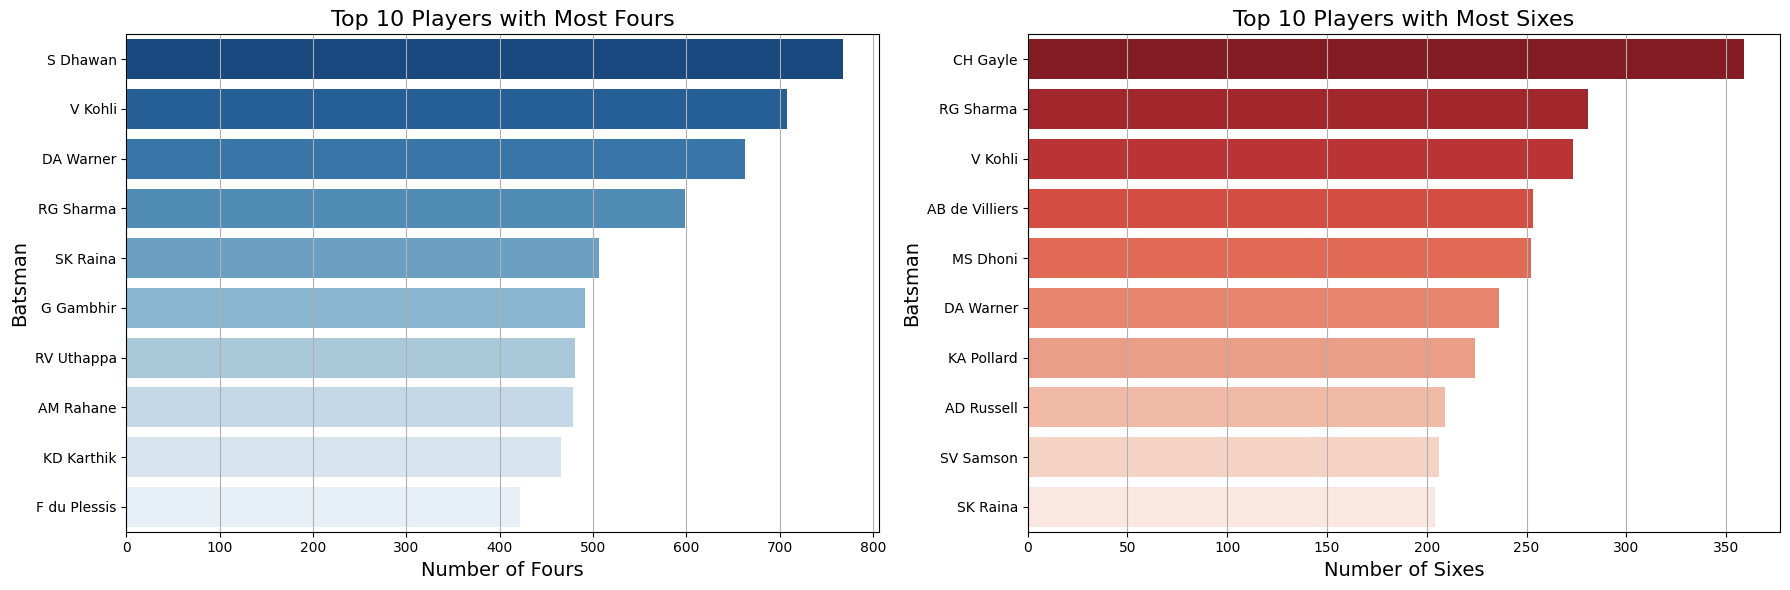

In [201]:
# Plot
fig, axs = plt.subplots(1, 2, figsize=(18,6))

# Fours Plot
sns.barplot(x=total_4s.values, y=total_4s.index, ax=axs[0], palette='Blues_r')
axs[0].set_title('Top 10 Players with Most Fours', fontsize=16)
axs[0].set_xlabel('Number of Fours', fontsize=14)
axs[0].set_ylabel('Batsman', fontsize=14)
axs[0].grid(axis='x')

# Sixes Plot
sns.barplot(x=total_6s.values, y=total_6s.index, ax=axs[1], palette='Reds_r')
axs[1].set_title('Top 10 Players with Most Sixes', fontsize=16)
axs[1].set_xlabel('Number of Sixes', fontsize=14)
axs[1].set_ylabel('Batsman', fontsize=14)
axs[1].grid(axis='x')

plt.tight_layout()
plt.show()


<h2>Matches vs Total Runs</h2>

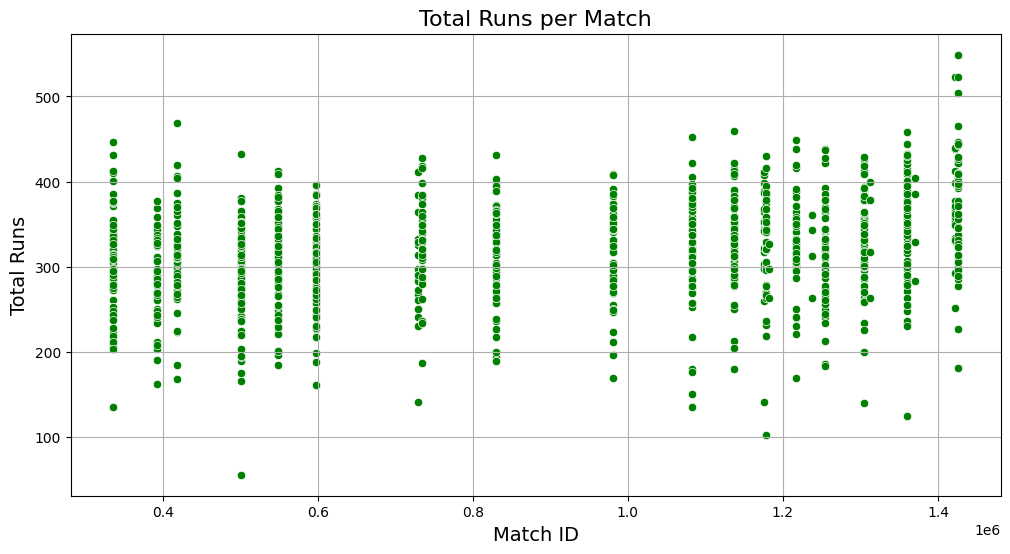

In [203]:
# Total runs per match
match_total_runs = deliveries.groupby('match_id')['total_runs'].sum().reset_index()

# Scatter plot
plt.figure(figsize=(12,6))
sns.scatterplot(x='match_id', y='total_runs', data=match_total_runs, color='green')
plt.title('Total Runs per Match', fontsize=16)
plt.xlabel('Match ID', fontsize=14)
plt.ylabel('Total Runs', fontsize=14)
plt.grid(True)
plt.show()
